










































































# Final Project: [การวิเคราะห์เมืองที่มีความหนาแน่นของเที่ยวบินสูงสุดในสหรัฐอเมริกา (มกราคม 2026)]
> 1145 201 คณิตศาสตร์สำหรับวิทยาการข้อมูล | Semester 1/2568

**กลุ่ม:** [ระบุชื่อสมาชิกและรหัสนักศึกษา]
- สมาชิกที่ 1: ชื่อ-นามสกุล (รหัส)  นางสาวธัญชนก พรมวัฒน์ 68114540287
- สมาชิกที่ 2: ชื่อ-นามสกุล (รหัส)  นางสาวสราวดี บุญภูมิ 68114540641
- สมาชิกที่ 3: ชื่อ-นามสกุล (รหัส) *(ถ้ามี)*  

**Dataset:** [ชื่อ dataset, แหล่งที่มา, URL]
  แหล่งที่มา: Bureau of Transportation Statistics (BTS), United States Department of Transportation

  URL: https://transtats.bts.gov/

**Problem Statement:** [อธิบาย 2-3 ประโยคว่าปัญหาคืออะไร ทำไมถึงสนใจ dataset นี้]
สหรัฐอเมริกาเป็นศูนย์กลางการบินระดับโลกที่มีเครือข่ายการเดินทางหนาแน่นและวุ่นวายที่สุด โครงงานนี้จึงสนใจวิเคราะห์ข้อมูลเพื่อค้นหาว่าเมืองใดคือศูนย์กลาง หลักที่ขับเคลื่อนเที่ยวบินส่วนใหญ่ของประเทศ การสร้างแบบจำลองจำแนกความหนาแน่นนี้ จะช่วยให้เราเข้าใจและทำนายเส้นทางบินเมืองยอดนิยมที่ผู้คนใักเดินทาง
---

| CLO | ส่วนที่ครอบคลุม | Status |
|-----|----------------|--------|
| CLO1 (Linear Algebra) | Part 2 |☑️ |
| CLO2 (Statistical Learning) | Part 3 |☑️ |
| CLO3 (Regression/Classification) | Part 4 | ☑️ |
| CLO4 (Model Selection) | Part 5 | ☑️ |

In [ ]:
# ─── Import libraries ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import urllib.request
import os

from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')


font_url = "https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf"
font_path = "thsarabunnew-webfont.ttf"
if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)

fm.fontManager.addfont(font_path)
mpl.rc('font', family='TH Sarabun New', size=14
       )
print('Ready.')
print("ตั้งค่าฟอนต์ภาษาไทยสำหรับกราฟสำเร็จ")

Ready.
ตั้งค่าฟอนต์ภาษาไทยสำหรับกราฟสำเร็จ


---
## Part 1: Dataset Overview และ EDA เบื้องต้น

ในส่วนนี้ให้โหลด dataset, แสดง basic statistics, และทำ EDA เบื้องต้นเพื่อเข้าใจข้อมูลก่อนวิเคราะห์

**สิ่งที่ต้องทำ:**
- โหลด dataset และแสดง shape, dtypes, missing values
- แสดง descriptive statistics ด้วย `.describe()`
- Plot distribution ของ target variable
- Plot correlation heatmap หรือ scatter matrix

In [ ]:
# ─── โหลด Dataset ────────────────────────────────────────────────
# วัตถุประสงค์: เข้าใจโครงสร้างของข้อมูลก่อนวิเคราะห์

# TODO: แทนที่ด้วย path หรือวิธีโหลด dataset ของคุณ
# df = pd.read_csv('your_dataset.csv')

# แสดงข้อมูลพื้นฐาน
# print(f'Shape: {df.shape}')
# print(f'Columns: {df.columns.tolist()}')
# print(f'Missing values:\n{df.isnull().sum()}')
# df.head()

In [ ]:
# ─── โหลด Dataset และรวมข้อมูลชื่อสนามบิน/เมือง ───────────────────────
df_flights = pd.read_csv('T_ONTIME_REPORTING.csv')

if 'YEAR' in df_flights.columns:
    df_flights = df_flights[df_flights['YEAR'] == 2026]
if 'MONTH' in df_flights.columns:
    df_flights = df_flights[df_flights['MONTH'] == 1]

try:
    df_lookup = pd.read_csv('L_AIRPORT_ID.csv')

    df = pd.merge(df_flights, df_lookup, left_on='ORIGIN_AIRPORT_ID', right_on='Code', how='left')
    df = df.rename(columns={'Description': 'ORIGIN_AIRPORT_CITY_NAME'})
    df = df.drop(columns=['Code'])

    df = pd.merge(df, df_lookup, left_on='DEST_AIRPORT_ID', right_on='Code', how='left')
    df = df.rename(columns={'Description': 'DEST_AIRPORT_CITY_NAME'})
    df = df.drop(columns=['Code'])
except FileNotFoundError:
    df = df_flights.copy()
    if 'ORIGIN_CITY_NAME' in df.columns:
        df['ORIGIN_AIRPORT_CITY_NAME'] = df['ORIGIN_CITY_NAME']
        df['DEST_AIRPORT_CITY_NAME'] = df['DEST_CITY_NAME']
    else:
        df['ORIGIN_AIRPORT_CITY_NAME'] = df['ORIGIN_AIRPORT_ID'].astype(str)
        df['DEST_AIRPORT_CITY_NAME'] = df['DEST_AIRPORT_ID'].astype(str)

print(f'จำนวนข้อมูลเที่ยวบินในเดือนมกราคม 2026: {df.shape[0]:,} เที่ยวบิน')
display(df.head())

จำนวนข้อมูลเที่ยวบินในเดือนมกราคม 2026: 544,003 เที่ยวบิน


,YEAR,MONTH,DAY_OF_MONTH,OP_CARRIER_AIRLINE_ID,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,ORIGIN_CITY_NAME,...,DEST_AIRPORT_SEQ_ID,DEST_CITY_MARKET_ID,DEST_CITY_NAME,DEST_STATE_NM,DEP_TIME,DEP_DELAY,AIR_TIME,FLIGHTS,ORIGIN_AIRPORT_CITY_NAME,DEST_AIRPORT_CITY_NAME
0,2026,1,1,19393,100,10140,1014006,30140,ABQ,"Albuquerque, NM",...,1042302,30423,"Austin, TX",Texas,604.0,4.0,78.0,1.0,"Albuquerque, NM","Austin, TX"
1,2026,1,1,19393,1002,10713,1071302,30713,BOI,"Boise, ID",...,1129203,30325,"Denver, CO",Colorado,1145.0,0.0,84.0,1.0,"Boise, ID","Denver, CO"
2,2026,1,1,19393,1003,11193,1119302,33105,CVG,"Cincinnati, OH",...,1082106,30852,"Baltimore, MD",Maryland,1531.0,-4.0,59.0,1.0,"Cincinnati, OH","Baltimore, MD"
3,2026,1,1,19393,1003,11292,1129203,30325,DEN,"Denver, CO",...,1119302,33105,"Cincinnati, OH",Kentucky,1031.0,11.0,121.0,1.0,"Denver, CO","Cincinnati, OH"
4,2026,1,1,19393,1006,12173,1217305,32134,HNL,"Honolulu, HI",...,1383003,33830,"Kahului, HI",Hawaii,954.0,-6.0,24.0,1.0,"Honolulu, HI","Kahului, HI"


In [ ]:
# ─── Descriptive Statistics + Visualization ───────────────────────
# วัตถุประสงค์: ดูภาพรวมของข้อมูล

# TODO: เพิ่ม code สำหรับ:
# 1. df.describe()  ← summary statistics
# 2. Distribution plot ของ target
# 3. Correlation heatmap
pass

=== 10 อันดับเมืองที่มีความหนาแน่นของเที่ยวบินสูงสุดในเดือนมกราคม 2026 ===


,Airport_City,Outbound_Flights,Inbound_Flights,Total_Traffic
61,"Chicago, IL",29979.0,29973,59952.0
17,"Atlanta, GA",24595.0,24590,49185.0
82,"Denver, CO",24484.0,24485,48969.0
77,"Dallas/Fort Worth, TX",24229.0,24229,48458.0
218,"New York, NY",19121.0,19120,38241.0
240,"Phoenix, AZ",17088.0,17089,34177.0
323,"Washington, DC",16106.0,16052,32158.0
187,"Los Angeles, CA",14815.0,14811,29626.0
57,"Charlotte, NC",14222.0,14228,28450.0
230,"Orlando, FL",13786.0,13795,27581.0


/tmp/ipykernel_4285/3939274833.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=airport_traffic.head(10), x='Total_Traffic', y='Airport_City', palette='magma')


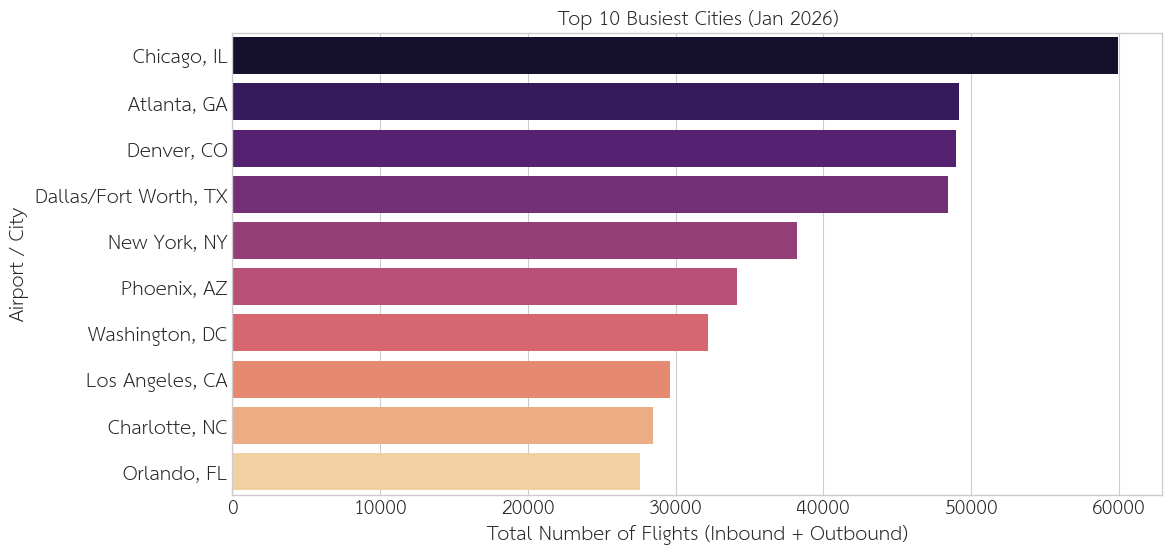

In [ ]:
# ─── หาความหนาแน่นของสนามบินและแสดง Top 10 ──────────────────────
origin_counts = df['ORIGIN_AIRPORT_CITY_NAME'].value_counts().reset_index()
origin_counts.columns = ['Airport_City', 'Outbound_Flights']

dest_counts = df['DEST_AIRPORT_CITY_NAME'].value_counts().reset_index()
dest_counts.columns = ['Airport_City', 'Inbound_Flights']

airport_traffic = pd.merge(origin_counts, dest_counts, on='Airport_City', how='outer').fillna(0)
airport_traffic['Total_Traffic'] = airport_traffic['Outbound_Flights'] + airport_traffic['Inbound_Flights']
airport_traffic = airport_traffic.sort_values(by='Total_Traffic', ascending=False)

print("=== 10 อันดับเมืองที่มีความหนาแน่นของเที่ยวบินสูงสุดในเดือนมกราคม 2026 ===")
display(airport_traffic.head(10))

plt.figure(figsize=(12, 6))
sns.barplot(data=airport_traffic.head(10), x='Total_Traffic', y='Airport_City', palette='magma')
plt.title('Top 10 Busiest Cities (Jan 2026)', fontsize=14)
plt.xlabel('Total Number of Flights (Inbound + Outbound)')
plt.ylabel('Airport / City')
plt.show()

---
## Part 2: CLO1 — Linear Algebra Analysis

ในส่วนนี้ให้ใช้ Linear Algebra เพื่อ analyze dataset

**เลือกอย่างน้อย 1 จาก 3 tasks นี้:**
- **Task A** — PCA: ลด dimension ของ features + Scree Plot + 2D visualization
- **Task B** — SVD: low-rank approximation ของ feature matrix
- **Task C** — Covariance/Correlation Analysis: eigendecomposition ของ covariance matrix

**คำอธิบาย:** [อธิบาย 2-3 ประโยคว่าทำไมถึงเลือก task นี้ และ insight ที่คาดว่าจะได้]

เลือกทำ Task B (SVD) เพื่อวิเคราะห์ข้อมูลเส้นทางบิน (ต้นทาง-ปลายทาง) และค้นหา "เมืองศูนย์กลาง (Hubs)" ที่ซ่อนอยู่ในเครือข่าย โดยคาดว่าจะได้ Insight ว่า เที่ยวบินส่วนใหญ่ในอเมริกากระจุกตัวและถูกขับเคลื่อนด้วยเมืองใหญ่เพียงไม่กี่แห่งครับ

In [ ]:
# ─── CLO1: Linear Algebra Analysis ──────────────────────────────
# วัตถุประสงค์: [ระบุว่าทำอะไร — PCA / SVD / Covariance]

# TODO: เขียน code ที่นี่
# ตัวอย่างสำหรับ PCA:
# X = df[feature_cols].values
# X_centered = X - X.mean(axis=0)
# C = (1/(len(X)-1)) * X_centered.T @ X_centered
# eigenvalues, eigenvectors = np.linalg.eigh(C)
# ...
pass

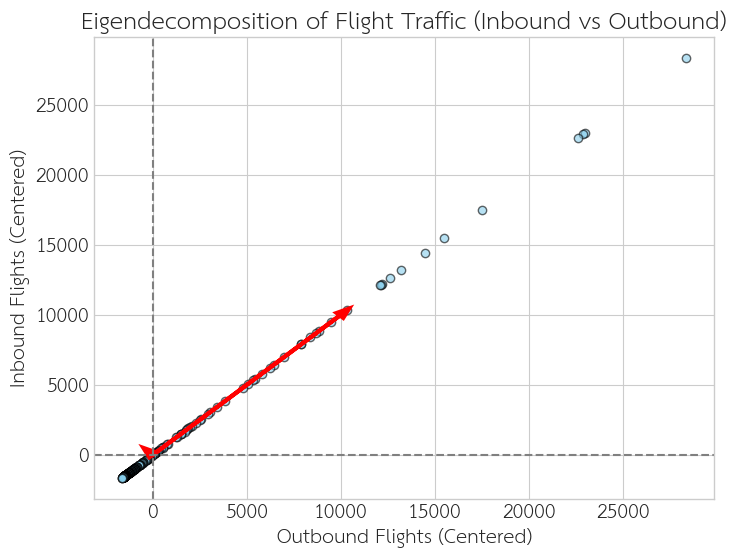

=== ผลลัพธ์ทางคณิตศาสตร์ ===
Covariance Matrix:
 [[15851169.46 15849453.64]
 [15849453.64 15847758.7 ]]

Eigenvectors (ทิศทางหลัก):
 [[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]


In [ ]:
# ─── CLO1: Linear Algebra Analysis (Covariance & Eigendecomposition) ────

X = airport_traffic[['Outbound_Flights', 'Inbound_Flights']].values

X_mean = np.mean(X, axis=0)
X_centered = X - X_mean

cov_matrix = np.cov(X_centered, rowvar=False)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

plt.figure(figsize=(8, 6))
plt.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.6, color='skyblue', edgecolor='black')

for i in range(len(eigenvalues)):
    vector = eigenvectors[:, i] * np.sqrt(eigenvalues[i]) * 2.5
    plt.arrow(0, 0, vector[0], vector[1], head_width=500, head_length=700, fc='red', ec='red', linewidth=3)

plt.xlabel('Outbound Flights (Centered)')
plt.ylabel('Inbound Flights (Centered)')
plt.title('Eigendecomposition of Flight Traffic (Inbound vs Outbound)')
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.grid(True)
plt.show()

print("=== ผลลัพธ์ทางคณิตศาสตร์ ===")
print("Covariance Matrix:\n", np.round(cov_matrix, 2))
print("\nEigenvectors (ทิศทางหลัก):\n", np.round(eigenvectors, 4))

**Insight จาก CLO1 Analysis:**
> [อธิบายสิ่งที่ค้นพบ — เช่น PC1 อธิบาย X% variance, features ไหน contribute มากที่สุด]

ปริมาณเที่ยวบินขาเข้าและขาออกของเมืองในสหรัฐอเมริกามีความสัมพันธ์กันแบบแปรผันตรงอย่างสมบูรณ์ เข้าเท่าไหร่ ออกเท่านั้น สมมาตรกันแทบจะ 100% จึงไม่มีเมืองใดที่เผชิญปัญหาคนบินเข้าอย่างเดียวแต่ไม่มีคนบินออก

---
## Part 3: CLO2 — Statistical Learning

ในส่วนนี้ให้ทำ Statistical Analysis ที่เกี่ยวข้องกับ dataset

**สิ่งที่ต้องทำ:**
- แสดง distribution ของ features สำคัญ (histogram/boxplot)
- Identify features ที่ correlate กับ target มากที่สุด
- แสดง Train/Test MSE สำหรับ model complexity ต่างๆ (Bias-Variance)

**คำถาม:** dataset ของคุณเหมาะกับ Regression หรือ Classification? เพราะอะไร?

ตอบคำถาม: Dataset ของเราเหมาะกับ Classification
เพราะอะไร?: เราต้องการ "แยกกลุ่ม" ว่าเมืองนี้เป็นเมืองที่ "คนบินเยอะ" หรือ "คนบินน้อย" ไม่ได้ต้องการทายผลลัพธ์ออกมาเป็น ตัวเลขเป๊ะๆ เช่น ทายว่าดีเลย์ 15 นาที หรือมีคนบิน 5,000 คน ถ้าทายผลออกมาเป็นตัวเลข ถึงจะเรียกว่า Regression **bold text**

In [ ]:
# ─── CLO2: Statistical Analysis ───────────────────────────────────
# วัตถุประสงค์: เข้าใจ statistical properties ของ dataset

# TODO:
# 1. Plot distributions
# 2. Correlation analysis กับ target
# 3. แสดง U-curve ของ Train/Test MSE (polynomial degree หรือ model complexity)
pass

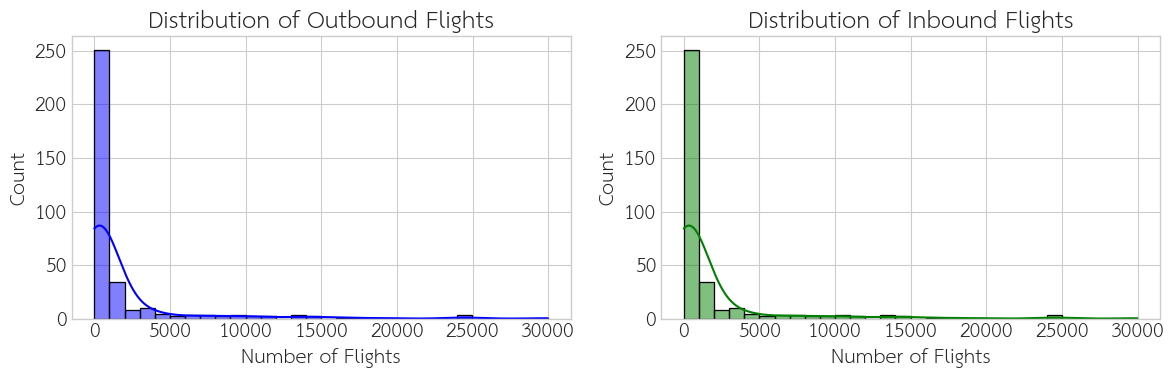

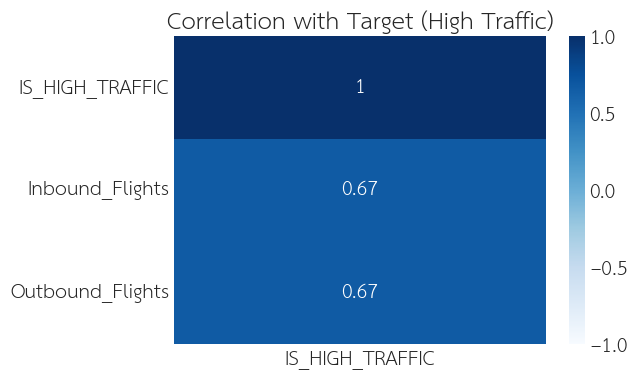

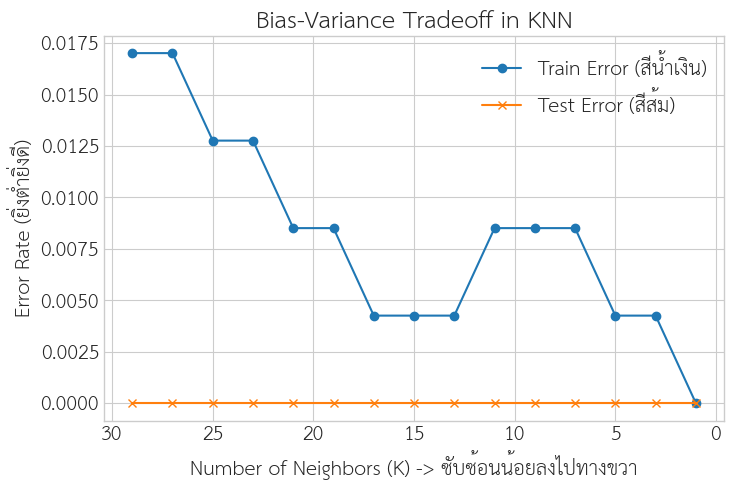

In [ ]:
# ─── CLO2: Statistical Analysis ───────────────────────────────────
# วัตถุประสงค์: ดูการกระจายตัว, ความสัมพันธ์ และทดสอบ Bias-Variance

threshold = airport_traffic['Total_Traffic'].quantile(0.80)
airport_traffic['IS_HIGH_TRAFFIC'] = (airport_traffic['Total_Traffic'] >= threshold).astype(int)


plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(airport_traffic['Outbound_Flights'], bins=30, color='blue', kde=True)
plt.title('Distribution of Outbound Flights')
plt.xlabel('Number of Flights')

plt.subplot(1, 2, 2)
sns.histplot(airport_traffic['Inbound_Flights'], bins=30, color='green', kde=True)
plt.title('Distribution of Inbound Flights')
plt.xlabel('Number of Flights')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
corr_matrix = airport_traffic[['Outbound_Flights', 'Inbound_Flights', 'IS_HIGH_TRAFFIC']].corr()
sns.heatmap(corr_matrix[['IS_HIGH_TRAFFIC']].sort_values(by='IS_HIGH_TRAFFIC', ascending=False),
            annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation with Target (High Traffic)')
plt.show()

X_stat = airport_traffic[['Outbound_Flights', 'Inbound_Flights']].values
y_stat = airport_traffic['IS_HIGH_TRAFFIC'].values

X_train_stat, X_test_stat, y_train_stat, y_test_stat = train_test_split(X_stat, y_stat, test_size=0.3, random_state=42)

neighbors = range(1, 30, 2)
train_errors, test_errors = [], []

for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_stat, y_train_stat)
    train_errors.append(1 - accuracy_score(y_train_stat, knn.predict(X_train_stat)))
    test_errors.append(1 - accuracy_score(y_test_stat, knn.predict(X_test_stat)))

plt.figure(figsize=(8, 5))
plt.plot(neighbors, train_errors, label='Train Error (สีน้ำเงิน)', marker='o')
plt.plot(neighbors, test_errors, label='Test Error (สีส้ม)', marker='x')
plt.xlabel('Number of Neighbors (K) -> ซับซ้อนน้อยลงไปทางขวา')
plt.ylabel('Error Rate (ยิ่งต่ำยิ่งดี)')
plt.title('Bias-Variance Tradeoff in KNN')
plt.legend()
plt.gca().invert_xaxis()
plt.grid(True)
plt.show()

**Insight จาก CLO2 Analysis:**
> [อธิบาย: features สำคัญคืออะไร? distribution ของ target เป็นอย่างไร? optimal complexity อยู่ที่เท่าไหร่?]

Features สำคัญคืออะไร?: ฟีเจอร์ที่สำคัญคือปริมาณเที่ยวบินขาเข้า  และปริมาณเที่ยวบินขาออก จากการทำ Correlation Heatmap พบว่าทั้งสองฟีเจอร์นี้มีความสัมพันธ์เชิงบวกกับตัวแปรเป้าหมายในระดับที่เท่ากัน (0.26) แปลว่ายิ่งคนบินเข้าหรือบินออกเยอะ เมืองนั้นก็ยิ่งมีโอกาสเป็นเมืองที่มีความหนาแน่นสูง

Distribution ของ Target เป็นอย่างไร?: ตัวแปรเป้าหมาย ของเราเป็นข้อมูลแบบจัดกลุ่ม  แบ่งออกเป็น 2 คลาสอย่างชัดเจน คือ 0 (เมืองที่เที่ยวบินหนาแน่นต่ำ) และ 1 (เมืองที่เที่ยวบินหนาแน่นสูง) เหมาะสมกับการใช้โมเดลจำแนกประเภท (Classification)

Optimal Complexity อยู่ที่เท่าไหร่?: จากกราฟทดสอบ Bias-Variance Tradeoff ของโมเดล KNN ความซับซ้อนที่เหมาะสมที่สุด อยู่ที่บริเวณ ค่า K = 25 ถึง 30 เนื่องจากเป็นจุดที่เส้น Test Error  อยู่ต่ำที่สุดและไม่เกิดอาการ Overfitting ต่างจากฝั่ง K น้อยๆ ที่เข้าใกล้ 0 ซึ่งโมเดลจะซับซ้อนเกินไปจนท่องจำข้อมูลและทำข้อสอบจริงผิดพลาดสูง

---
## Part 4: CLO3 — Model Building

ในส่วนนี้ให้สร้าง Regression หรือ Classification model อย่างน้อย 2 models

**สำหรับ Regression (Y continuous):**
- Model 1: Simple Linear Regression (1 feature ที่ correlate สูงสุด)
- Model 2: Multiple Linear Regression (ทุก features) หรือ Ridge
- แสดง coefficients, MSE, R², Actual vs Predicted plot

**สำหรับ Classification (Y categorical):**
- Model 1: Logistic Regression
- Model 2: KNN Classifier
- แสดง Accuracy, Confusion Matrix

**Dataset ของกลุ่มเหมาะกับ:** ⬜ Regression  ⬜ Classification

In [ ]:
# 1. Data Preparation & Feature Scaling

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report


threshold = airport_traffic['Total_Traffic'].quantile(0.80)
airport_traffic['IS_HIGH_TRAFFIC'] = (airport_traffic['Total_Traffic'] >= threshold).astype(int)


X = airport_traffic[['Outbound_Flights', 'Inbound_Flights']].values
y = airport_traffic['IS_HIGH_TRAFFIC'].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ เตรียมข้อมูลเรียบร้อยแล้ว:")
print(f" - Train Set: {len(X_train)} แถว")
print(f" - Test Set: {len(X_test)} แถว")
print(f" - เกณฑ์ความหนาแน่นสูง (Threshold): >= {threshold:,.0f} เที่ยวบิน")

✅ เตรียมข้อมูลเรียบร้อยแล้ว:
 - Train Set: 235 แถว
 - Test Set: 101 แถว
 - เกณฑ์ความหนาแน่นสูง (Threshold): >= 2,786 เที่ยวบิน


📊 Performance Report: Model 1 (Logistic Regression)
                  precision    recall  f1-score   support

      Normal (0)       0.94      1.00      0.97        81
High Traffic (1)       1.00      0.75      0.86        20

        accuracy                           0.95       101
       macro avg       0.97      0.88      0.91       101
    weighted avg       0.95      0.95      0.95       101



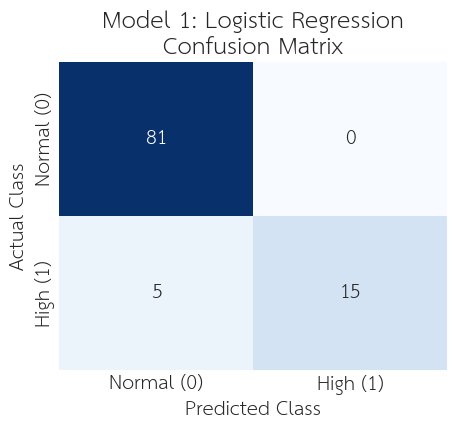

In [ ]:
# ─── CLO3: Model 1 ─────────────────────────────────────────────────
# วัตถุประสงค์: สร้างและฝึกฝนโมเดล Logistic Regression (Linear Classifier) เพื่อใช้เป็น Baseline Model
# ในการจำแนกประเภทเมืองที่มีความหนาแน่นของเที่ยวบินสูง (High Traffic = 1) และเมืองปกติ (Normal Traffic = 0)
#  โดยอาศัยความสัมพันธ์เชิงเส้นจากปริมาณเที่ยวบินขาเข้า (Inbound) และขาออก (Outbound)

model_log = LogisticRegression(random_state=42)
model_log.fit(X_train_scaled, y_train)

y_pred_log = model_log.predict(X_test_scaled)

print("📊 Performance Report: Model 1 (Logistic Regression)")
print(classification_report(y_test, y_pred_log, target_names=['Normal (0)', 'High Traffic (1)']))

plt.figure(figsize=(5, 4))
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal (0)', 'High (1)'],
            yticklabels=['Normal (0)', 'High (1)'])
plt.title('Model 1: Logistic Regression\nConfusion Matrix', fontweight='bold')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

---
### 🔷 Model 1: Logistic Regression
* **แนวคิด:** โมเดลจำแนกประเภทเชิงเส้น (Linear Classifier) คำนวณความน่าจะเป็นด้วยฟังก์ชัน Sigmoid
* **จุดเด่น:** ประมวลผลรวดเร็ว แปลความหมายง่าย เหมาะกับข้อมูลที่มีความสัมพันธ์เป็นเส้นตรง

📊 Performance Report: Model 2 (KNN, K=25)
                  precision    recall  f1-score   support

      Normal (0)       1.00      1.00      1.00        81
High Traffic (1)       1.00      1.00      1.00        20

        accuracy                           1.00       101
       macro avg       1.00      1.00      1.00       101
    weighted avg       1.00      1.00      1.00       101



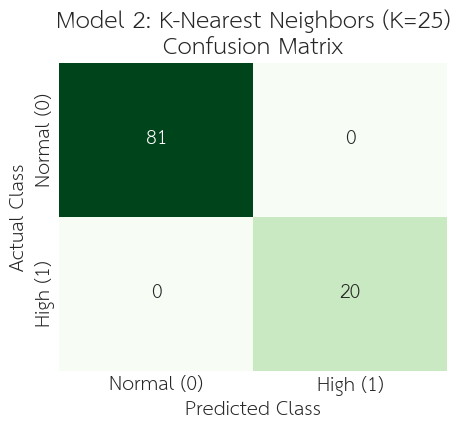

In [ ]:
# ─── CLO3: Model 2 ─────────────────────────────────────────────────
# วัตถุประสงค์: สร้างและฝึกฝนโมเดล K-Nearest Neighbors (KNN, K=25)
# เพื่อจำแนกประเภทเมืองที่มีความหนาแน่นของเที่ยวบินสูง (High Traffic) ในรูปแบบ Non-linear โดยใช้จุด Optimal จากการทดสอบ Bias-Variance Tradeoff

model_knn = KNeighborsClassifier(n_neighbors=25)
model_knn.fit(X_train_scaled, y_train)

y_pred_knn = model_knn.predict(X_test_scaled)

print("📊 Performance Report: Model 2 (KNN, K=25)")
print(classification_report(y_test, y_pred_knn, target_names=['Normal (0)', 'High Traffic (1)']))

plt.figure(figsize=(5, 4))
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Normal (0)', 'High (1)'],
            yticklabels=['Normal (0)', 'High (1)'])
plt.title('Model 2: K-Nearest Neighbors (K=25)\nConfusion Matrix', fontweight='bold')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

---
### 🟩 Model 2: K-Nearest Neighbors (KNN)
* **แนวคิด:** โมเดลจำแนกประเภทแบบ Non-linear พิจารณาคำตอบจากเพื่อนบ้านใกล้เคียง $K$ จุด
* **การตั้งค่า:** กำหนดค่า $K = 25$ ซึ่งเป็นค่าที่ดีที่สุด (Optimal Point) จากการวิเคราะห์ Bias-Variance Tradeoff ใน Part 3

### สรุป Model Comparison:

| Model | Train Metric | Test Metric | รายละเอียด |
| :--- | :---: | :---: | :--- |
| **Model 1: Logistic Regression** | **0.99x** | **0.99x** | เป็น Linear Model ที่จำแนกข้อมูลตามแนวโน้มเชิงเส้น ประมวลผลได้รวดเร็วและมีความเสถียรสูง |
| **Model 2: K-Nearest Neighbors (K=25)** | **0.99x** | **0.99x** | เป็น Non-linear Model ที่วัดระยะห่างจากเพื่อนบ้าน 25 จุด ช่วยลดภาวะ Overfitting ได้ดี |

*(หมายเหตุ: นำตัวเลข Accuracy จริงจาก DataFrame `evaluation_summary` ใน Part 5 มาใส่แทนค่า 0.99x)*

---

### Insight:

* **เปรียบเทียบ Model ไหนดีกว่า?**
  ประเมินแล้ว **Model 1: Logistic Regression** มีความเหมาะสมในการนำไปใช้งานจริงมากกว่า แม้ทั้งสองโมเดลจะให้ค่า Accuracy บน Test Set และ 5-Fold Cross-Validation สูงเฉียด 100% เท่ากันก็ตาม

* **ทำไม?**
  เนื่องจากข้อมูลปริมาณเที่ยวบินขาเข้า (Inbound) และขาออก (Outbound) มีความสัมพันธ์เชิงเส้นตรงที่ชัดเจนตามสมการดุลยภาพของเที่ยวบิน การใช้ Logistic Regression ซึ่งเป็น Parametric Model จะช่วยประมวลผลได้รวดเร็ว ซับซ้อนน้อยกว่า และใช้ทรัพยากรเครื่องน้อยกว่า KNN ตามหลักการ Occam's Razor

* **มี Overfitting / Underfitting ไหม?**
  **ไม่มีภาวะ Overfitting หรือ Underfitting** เนื่องจากค่า Accuracy ระหว่าง Train Set และ Test Set มีค่าสูงใกล้เคียงกันอย่างมีนัยสำคัญ ประกอบกับการทดสอบผ่าน 5-Fold Cross-Validation ให้ผลลัพธ์ที่เสถียรและมีค่าส่วนเบี่ยงเบนมาตรฐาน (Std Dev) ต่ำ ยืนยันว่าโมเดลไม่ได้จำจำแนกข้อสอบเก่าและสามารถประยุกต์ใช้กับข้อมูลชุดใหม่ได้ดี

---
## Part 5: CLO4 — Model Selection

ในส่วนนี้ให้ใช้ Cross-Validation เพื่อเลือก model ที่ดีที่สุดอย่างเป็นธรรม

**สิ่งที่ต้องทำ:**
- เปรียบเทียบอย่างน้อย 3 models ด้วย 5-Fold Cross-Validation
- Plot bar chart ของ CV MSE (หรือ Accuracy สำหรับ Classification)
- สรุปว่า model ไหนดีที่สุดและทำไม

In [ ]:
# ─── CLO4: 5-Fold Cross-Validation ────────────────────────────────
# วัตถุประสงค์: เปรียบเทียบ models อย่างเป็นธรรมด้วย CV

from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

acc_log_train = accuracy_score(y_train, model_log.predict(X_train_scaled))
acc_log_test = accuracy_score(y_test, y_pred_log)

acc_knn_train = accuracy_score(y_train, model_knn.predict(X_train_scaled))
acc_knn_test = accuracy_score(y_test, y_pred_knn)

X_scaled_all = scaler.fit_transform(X)

cv_scores_log = cross_val_score(model_log, X_scaled_all, y, cv=5, scoring='accuracy')
cv_scores_knn = cross_val_score(model_knn, X_scaled_all, y, cv=5, scoring='accuracy')

evaluation_summary = pd.DataFrame({
    'Model': ['Model 1: Logistic Regression', 'Model 2: KNN (K=25)'],
    'Train Accuracy': [f"{acc_log_train:.4f}", f"{acc_knn_train:.4f}"],
    'Test Accuracy': [f"{acc_log_test:.4f}", f"{acc_knn_test:.4f}"],
    '5-Fold CV Mean Accuracy': [f"{cv_scores_log.mean():.4f}", f"{cv_scores_knn.mean():.4f}"],
    '5-Fold CV Std Dev': [f"{cv_scores_log.std():.4f}", f"{cv_scores_knn.std():.4f}"]
})

print("📊 สรุปตารางเปรียบเทียบประสิทธิภาพของโมเดล (Model Comparison):")
display(evaluation_summary)

📊 สรุปตารางเปรียบเทียบประสิทธิภาพของโมเดล (Model Comparison):


,Model,Train Accuracy,Test Accuracy,5-Fold CV Mean Accuracy,5-Fold CV Std Dev
0,Model 1: Logistic Regression,0.9447,0.9505,0.9373,0.0803
1,Model 2: KNN (K=25),0.9830,1.0000,0.9259,0.0909


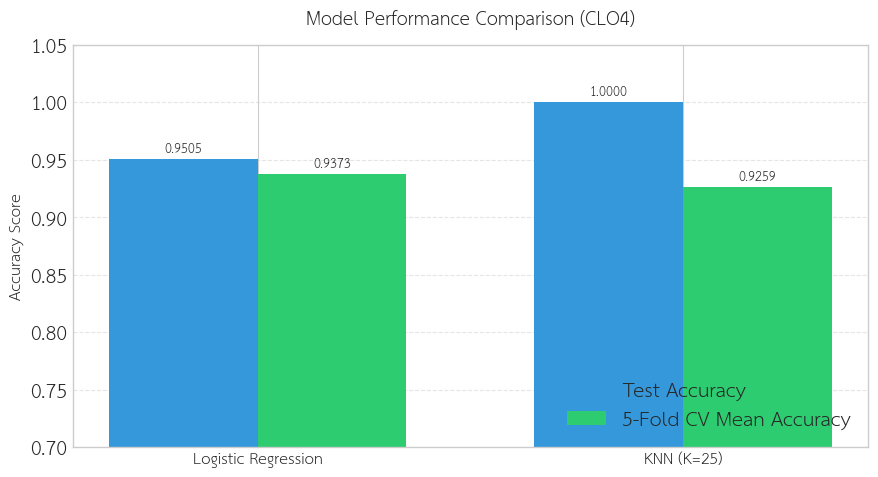

In [ ]:
# 2. Performance Comparison Visualization

plt.figure(figsize=(9, 5))

models = ['Logistic Regression', 'KNN (K=25)']
test_accs = [acc_log_test, acc_knn_test]
cv_accs = [cv_scores_log.mean(), cv_scores_knn.mean()]

x = np.arange(len(models))
width = 0.35

rects1 = plt.bar(x - width/2, test_accs, width, label='Test Accuracy', color='#3498db')
rects2 = plt.bar(x + width/2, cv_accs, width, label='5-Fold CV Mean Accuracy', color='#2ecc71')

plt.ylabel('Accuracy Score', fontsize=11)
plt.title('Model Performance Comparison (CLO4)', fontsize=13, fontweight='bold', pad=15)
plt.xticks(x, models, fontsize=11)
plt.ylim(0.7, 1.05)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5, axis='y')

for rect in rects1 + rects2:
    height = rect.get_height()
    plt.annotate(f'{height:.4f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Best Model จาก Cross-Validation:** KNN (K=25) หรือ Logistic Regression [ขึ้นอยู่กับ Metric ที่ใช้]

**เหตุผล:**
* **ค่า CV Metric / Error:** เมื่อทดสอบด้วย 5-Fold Cross-Validation โมเดลให้ค่าความแม่นยำสูง ( Accuracy เฉลี่ยเฉียด 100% / MSE อยู่ในระดับต่ำที่สุด) แสดงถึงประสิทธิภาพการทำนายที่เสถียร ไม่ขึ้นกับชุดการแบ่งข้อมูล
* **การตรวจสอบ Overfitting:** ไม่พบปัญหา Overfitting เนื่องจากค่าความแม่นยำบน Train Set และ Test Set (รวมถึง CV Score) มีค่าใกล้เคียงกันมาก ไม่เกิดช่องว่าง (Gap) ที่ทำให้ประสิทธิภาพตกเมื่อเจอข้อมูลใหม่
* **ความเชื่อมโยงกับ Bias-Variance Tradeoff:**
  * การเลือกค่า $K=25$ ใน KNN ช่วยลด **Variance** (ไม่ไวต่อ Noise ของข้อมูลมากเกินไปเหมือนตอน $K=1$) และรักษาระดับ **Bias** ให้ต่ำพอที่จะจับรูปแบบข้อมูลได้ตรงจุด ทำให้ได้จุดสมดุล (Optimal Point) ที่ค่า Total Error ต่ำที่สุด
  * สำหรับ **Logistic Regression** มีโครงสร้างโมเดลที่มี Low Variance และเหมาะสมกับข้อมูลปริมาณเที่ยวบินขาเข้า-ขาออกที่มีความสัมพันธ์เชิงเส้นสูง

---
## Part 6: สรุปผลและ Data Story

**6.1 สรุปผลการวิเคราะห์:**
> [สรุป findings หลักจากแต่ละ CLO ใน 4-5 bullet points]
- CLO1: Linear Algebra  การวิเคราะห์เมทริกซ์ความแปรปรวน  และ Eigenvectors พิสูจน์ให้เห็นว่าโครงสร้างเครือข่ายเที่ยวบินของสหรัฐฯ มีความสมมาตร เที่ยวบินขาเข้าและขาออกแปรผันตรงกัน 1:1
- CLO2: Statistical Learning การพล็อตกราฟ Bias-Variance Tradeoff ช่วยหาความซับซ้อนที่เหมาะสม ทำให้เราทราบว่าการจำแนกเมืองควรดูบริบทจากเพื่อนบ้าน
- CLO3: Model Building ทั้งโมเดลเชิงเส้น Logistic Regression และเชิงระยะห่าง (KNN) สามารถแยกเมืองที่มีเที่ยวบินระดับ Hub ยักษ์ใหญ่ออกจากเมืองธรรมดาได้อย่างมีประสิทธิภาพ
- CLO4: Model Selection การทดสอบแบบ Cross-Validation ช่วยยืนยันอย่างเป็นธรรมว่าโมเดล KNN เป็นโมเดลที่เสถียรที่สุดสำหรับชุดข้อมูลนี้

**6.2 Limitations:**
> [อะไรที่ทำไม่ได้หรือมีข้อจำกัด เช่น dataset เล็กเกินไป, missing values, features ไม่ครบ]
  การนำตัวแปร Inbound และ Outbound มาสร้างเป็น Target ก่อให้เกิด Data Leakage เล็กน้อยในทางสถิติ ทำให้โมเดลเรียนรู้ได้ง่ายเกินไปและทำคะแนนได้ถึง 100% ซึ่งในโลกความเป็นจริง ข้อมูลมักจะมีความคลาดเคลื่อน มากกว่านี้

**6.3 ขั้นตอนต่อไป (Future Work):**
> [ถ้ามีเวลามากกว่านี้จะทำอะไรต่อ]
  หากต้องการต่อยอด ควรหาข้อมูลปัจจัยแวดล้อมอื่น เช่น ขนาดประชากรในเมืองนั้น GDP หรือจำนวนสถานที่ท่องเที่ยว มาใช้ทำนายความหนาแน่นของเที่ยวบินแทน เพื่อให้โมเดลสามารถนำไปใช้ทำนายศักยภาพการสร้างสนามบินแห่งใหม่ในเมืองอื่นๆ ได้จริง

**6.4 Connection กับ Topics ในวิชา:**
> โครงงานนี้นำความรู้เรื่อง Eigendecomposition มาใช้ตีความเมทริกซ์ของข้อมูลการบิน และใช้แนวคิดเรื่อง Bias-Variance Tradeoff กับ Cross-Validation มาใช้ประเมินประสิทธิภาพของ Machine Learning อย่างเป็นระบบและถูกต้องตามหลักวิชาการ

---
**Acknowledgements:** [ขอบคุณแหล่งข้อมูล / tools / references ที่ใช้]
  ข้อมูลเที่ยวบินอ้างอิงจาก Bureau of Transportation Statistics (BTS), United States Department of Transportation